<a href="https://colab.research.google.com/github/jaxa4ever-code/Logistic-Regression/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Test Hours Studied:
 [5.  4.5 0.5]
Predicted Outcomes (0=Fail, 1=Pass):
 [1 1 0]
Predicted Probabilities of Passing:
 [0.95 0.9  0.04]

A student studying 2.3 hours is predicted to: FAIL
Confidence/Probability of passing: 30.7%


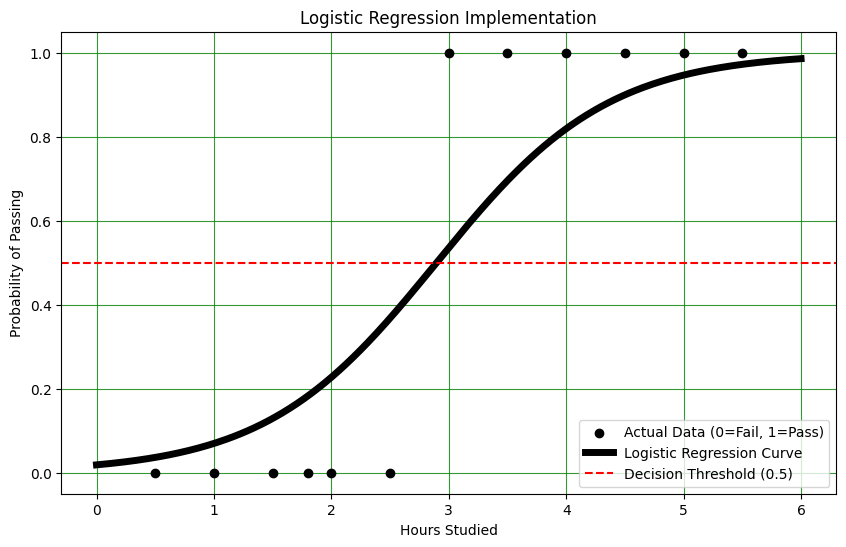

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


X = np.array([[0.5], [1.0], [1.5], [1.8], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Test Hours Studied:\n", X_test.flatten())
print("Predicted Outcomes (0=Fail, 1=Pass):\n", y_pred)
print("Predicted Probabilities of Passing:\n", np.round(y_prob, 2))

custom_student = [[2.3]]
prediction = model.predict(custom_student)
probability = model.predict_proba(custom_student)[0][1]

print(f"\nA student studying 2.3 hours is predicted to: {'PASS' if prediction[0] == 1 else 'FAIL'}")
print(f"Confidence/Probability of passing: {probability * 100:.1f}%")

X_curve = np.linspace(0, 6, 300).reshape(-1, 1)
y_curve_prob = model.predict_proba(X_curve)[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Data (0=Fail, 1=Pass)', zorder=5)
plt.plot(X_curve, y_curve_prob, color='black', linewidth=5, label='Logistic Regression Curve')

plt.axhline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.title('Logistic Regression Implementation')
plt.xlabel('Hours Studied')
plt.ylabel('Probability of Passing')
plt.legend(loc='lower right')
plt.grid(alpha=0.8, color ='green')
plt.show()
